[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


First 5 Rows of Dataset:

                                             Comment Emotion
0  i seriously hate one subject to death but now ...    fear
1                 im so full of life i feel appalled   anger
2  i sit here to write i start to dig out my feel...    fear
3  ive been really angry with r and i feel like a...     joy
4  i feel suspicious if there is no one outside l...    fear


DATASET SHAPE:
(5937, 2)

COLUMN NAMES:
Index(['Comment', 'Emotion'], dtype='object')

MISSING VALUES:
Comment    0
Emotion    0
dtype: int64

DATASET INFORMATION:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5937 entries, 0 to 5936
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Comment  5937 non-null   object
 1   Emotion  5937 non-null   object
dtypes: object(2)
memory usage: 92.9+ KB
None


EMOTION LABEL COUNTS:

Emotion
anger    2000
joy      2000
fear     1937
Name: count, dtype: int64


TEXT PREPROCESSING COMPLETED SUCCESSFUL

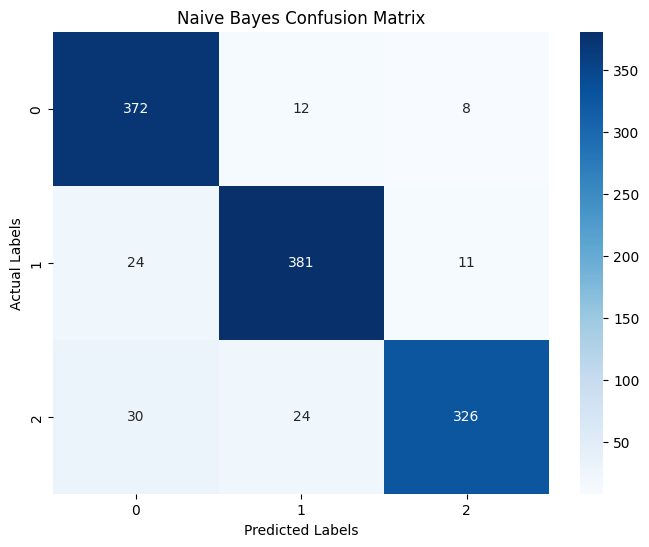


TRAINING SUPPORT VECTOR MACHINE (SVM)...

SVM MODEL TRAINED SUCCESSFULLY


SVM MODEL EVALUATION

Accuracy Score:
0.946969696969697

F1 Score:
0.9469121249090242

Classification Report:

              precision    recall  f1-score   support

       anger       0.93      0.96      0.94       392
        fear       0.97      0.92      0.94       416
         joy       0.95      0.96      0.95       380

    accuracy                           0.95      1188
   macro avg       0.95      0.95      0.95      1188
weighted avg       0.95      0.95      0.95      1188




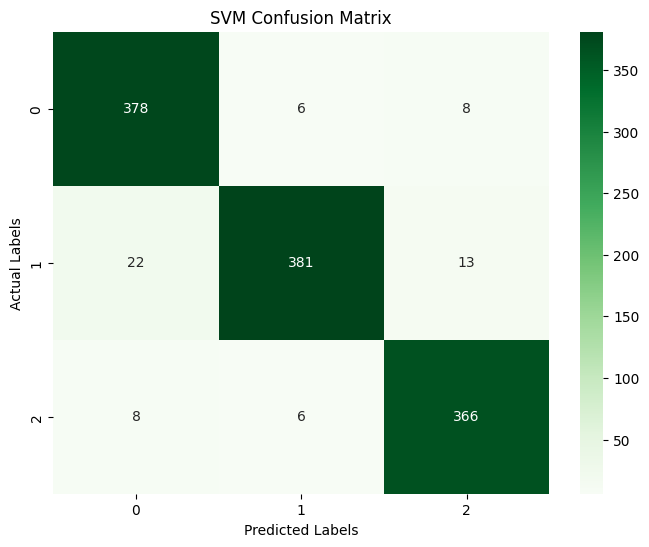


MODEL COMPARISON TABLE

                    Model  Accuracy  F1-Score
0             Naive Bayes  0.908249  0.908096
1  Support Vector Machine  0.946970  0.946912



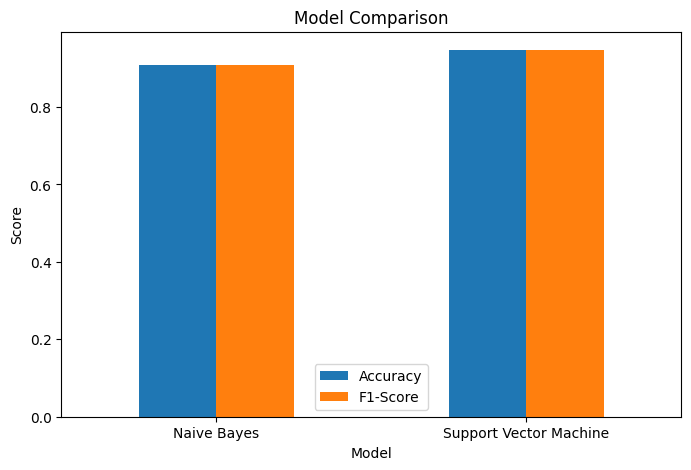

In [7]:
# ============================================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import re
import string

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 2. DOWNLOAD REQUIRED NLTK FILES
# ============================================================

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')


# ============================================================
# 3. LOAD DATASET
# ============================================================


df = pd.read_csv("nlp_dataset.csv")

# ============================================================
# 4. DISPLAY FIRST 5 ROWS
# ============================================================

print("First 5 Rows of Dataset:\n")
print(df.head())

print("\n============================================================")


# ============================================================
# 5. DATASET INFORMATION
# ============================================================

print("\nDATASET SHAPE:")
print(df.shape)

print("\nCOLUMN NAMES:")
print(df.columns)

print("\nMISSING VALUES:")
print(df.isnull().sum())

print("\nDATASET INFORMATION:")
print(df.info())

print("\n============================================================")


# ============================================================
# 6. CHECK TARGET LABELS
# ============================================================

print("\nEMOTION LABEL COUNTS:\n")
print(df['Emotion'].value_counts())

print("\n============================================================")


# ============================================================
# 7. TEXT PREPROCESSING

stop_words = set(stopwords.words('english'))

def preprocess_text(text):

    # Convert text to string
    text = str(text)

    # Convert text to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+", "", text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Join tokens back
    text = " ".join(tokens)

    return text


# ============================================================
# 8. APPLY PREPROCESSING
# ============================================================

# Dataset text column = Comment

df['Clean_Text'] = df['Comment'].apply(preprocess_text)

print("\nTEXT PREPROCESSING COMPLETED SUCCESSFULLY\n")

print(df[['Comment', 'Clean_Text']].head())

print("\n============================================================")


# ============================================================
# 9. PREPROCESSING EXPLANATION
# ============================================================

print("""
================ PREPROCESSING EXPLANATION ================

1. LOWERCASING:
   Converts all text into lowercase letters.

2. REMOVING URLS:
   Removes website links from text.

3. REMOVING NUMBERS:
   Removes numbers because they usually
   do not contribute to sentiment analysis.

4. REMOVING PUNCTUATION:
   Removes symbols such as ! ? , .

5. TOKENIZATION:
   Splits sentence into individual words.

6. STOPWORD REMOVAL:
   Removes common words such as:
   is, the, and, are

IMPACT ON MODEL PERFORMANCE:
- Reduces noise in text
- Improves prediction accuracy
- Makes training faster
- Helps model focus on meaningful words

============================================================
""")


# ============================================================
# 10. FEATURE EXTRACTION USING TF-IDF
# ============================================================

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['Clean_Text'])

y = df['Emotion']

print("\nTF-IDF FEATURE EXTRACTION COMPLETED\n")

print("TF-IDF Matrix Shape:")
print(X.shape)

print("\n============================================================")


# ============================================================
# 11. TF-IDF EXPLANATION
# ============================================================

print("""
================ TF-IDF EXPLANATION ========================

TF-IDF stands for:
Term Frequency - Inverse Document Frequency

HOW IT WORKS:

1. TERM FREQUENCY (TF):
   Measures how frequently a word appears
   in a sentence.

2. INVERSE DOCUMENT FREQUENCY (IDF):
   Measures importance of a word across all documents.

PURPOSE:
- Converts text into numerical vectors
- Machine learning models understand only numbers

ADVANTAGES:
- Gives importance to meaningful words
- Reduces importance of common words
- Improves text classification accuracy

============================================================
""")


# ============================================================
# 12. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTRAIN TEST SPLIT COMPLETED\n")

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

print("\n============================================================")


# ============================================================
# 13. MODEL DEVELOPMENT - NAIVE BAYES
# ============================================================

print("\nTRAINING NAIVE BAYES MODEL...\n")

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

# Predictions
nb_predictions = nb_model.predict(X_test)

print("NAIVE BAYES MODEL TRAINED SUCCESSFULLY")

print("\n============================================================")


# ============================================================
# 14. EVALUATE NAIVE BAYES MODEL
# ============================================================

nb_accuracy = accuracy_score(y_test, nb_predictions)

nb_f1 = f1_score(y_test, nb_predictions, average='weighted')

print("\nNAIVE BAYES MODEL EVALUATION\n")

print("Accuracy Score:")
print(nb_accuracy)

print("\nF1 Score:")
print(nb_f1)

print("\nClassification Report:\n")
print(classification_report(y_test, nb_predictions))

print("\n============================================================")


# ============================================================
# 15. CONFUSION MATRIX - NAIVE BAYES
# ============================================================

cm_nb = confusion_matrix(y_test, nb_predictions)

plt.figure(figsize=(8,6))

sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues')

plt.title("Naive Bayes Confusion Matrix")

plt.xlabel("Predicted Labels")

plt.ylabel("Actual Labels")

plt.show()


# ============================================================
# 16. MODEL DEVELOPMENT - SUPPORT VECTOR MACHINE
# ============================================================

print("\nTRAINING SUPPORT VECTOR MACHINE (SVM)...\n")

svm_model = SVC(kernel='linear')

svm_model.fit(X_train, y_train)

# Predictions
svm_predictions = svm_model.predict(X_test)

print("SVM MODEL TRAINED SUCCESSFULLY")

print("\n============================================================")


# ============================================================
# 17. EVALUATE SVM MODEL
# ============================================================

svm_accuracy = accuracy_score(y_test, svm_predictions)

svm_f1 = f1_score(y_test, svm_predictions, average='weighted')

print("\nSVM MODEL EVALUATION\n")

print("Accuracy Score:")
print(svm_accuracy)

print("\nF1 Score:")
print(svm_f1)

print("\nClassification Report:\n")
print(classification_report(y_test, svm_predictions))

print("\n============================================================")


# ============================================================
# 18. CONFUSION MATRIX - SVM
# ============================================================

cm_svm = confusion_matrix(y_test, svm_predictions)

plt.figure(figsize=(8,6))

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens')

plt.title("SVM Confusion Matrix")

plt.xlabel("Predicted Labels")

plt.ylabel("Actual Labels")

plt.show()


# ============================================================
# 19. MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame({
    'Model': ['Naive Bayes', 'Support Vector Machine'],
    'Accuracy': [nb_accuracy, svm_accuracy],
    'F1-Score': [nb_f1, svm_f1]
})

print("\nMODEL COMPARISON TABLE\n")

print(comparison)

print("\n============================================================")


# ============================================================
# 20. GRAPHICAL COMPARISON
# ============================================================

comparison.plot(
    x='Model',
    y=['Accuracy', 'F1-Score'],
    kind='bar',
    figsize=(8,5)
)

plt.title("Model Comparison")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()
